# Using commit vith onnx

In [1]:
from utils_dino_final_pylib import *
import onnxruntime
import time

def get_onnx_mask_from_bboxes_onnx(bboxes, ort_session):

    all_masks = []

    for bbox in bboxes:

        onnx_box_coords = bbox.reshape(2, 2)
        onnx_box_labels = np.array([2,3])

        onnx_coord = np.concatenate([ onnx_box_coords], axis=0)[None, :, :]
        onnx_label = np.concatenate([ onnx_box_labels], axis=0)[None, :].astype(np.float32)

        onnx_coord = predictor.transform.apply_coords(onnx_coord, image.shape[:2]).astype(np.float32)
        
        print("onnx_coord.shape", onnx_coord.shape)
        print("onnx_label.shape", onnx_label.shape)

        print(image.shape[:2])

        onnx_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
        onnx_has_mask_input = np.zeros(1, dtype=np.float32)


        ort_inputs = {
            "image_embeddings": image_embedding,
            "point_coords": onnx_coord,
            "point_labels": onnx_label,
            "mask_input": onnx_mask_input,
            "has_mask_input": onnx_has_mask_input,
            "orig_im_size": np.array(image.shape[:2], dtype=np.float32)
        }

        masks, _, _ = ort_session.run(None, ort_inputs)
        masks = masks > predictor.model.mask_threshold
        print("masks.shape", masks.shape)

        all_masks.append(masks)

    return all_masks

Using device: cuda
final text_encoder_type: bert-base-uncased


Getting wall mask from  D:\3d-recon\datasets\ASARoomImage\test\input.jpg


wall_bboxes [[1.2349213e+01 2.6789215e+01 8.7199890e+02 7.1330847e+02]
 [8.5554626e+02 1.8173920e+01 1.5023424e+03 8.0649341e+02]
 [7.3563004e-01 1.5610657e+00 1.1011426e+02 9.9001611e+02]
 [1.1037593e+03 5.4701660e+02 1.5028008e+03 8.1097925e+02]]
wall_selected_points [[426, 368], [940, 427], [36, 644], [1314, 672]]
RUG:  0
There is overlap
Subtract rug from floor area NOT OK. Revert to original Floor!
floor_bboxes [[  80.14337  618.74023 1502.8833   990.3489 ]]
floor_selected_points [[727, 735]]
rug_bboxes []
rug_to_floor_indices []
DONE GETTING BBOXES 2.955780506134033
(992, 1504, 3)
DONE SAM EMBEDDING 6.905946493148804
onnx_coord.shape (1, 2, 2)
onnx_label.shape (1, 2)
(992, 1504)
masks.shape (1, 1, 992, 1504)
onnx_coord.shape (1, 2, 2)
onnx_label.shape (1, 2)
(992, 1504)
masks.shape (1, 1, 992, 1504)
onnx_coord.shape (1, 2, 2)
onnx_label.shape (1, 2)
(992, 1504)
masks.shape (1, 1, 992, 1504)
onnx_coord.shape (1, 2, 2)
onnx_label.shape (1, 2)
(992, 1504)
masks.shape (1, 1, 992, 150

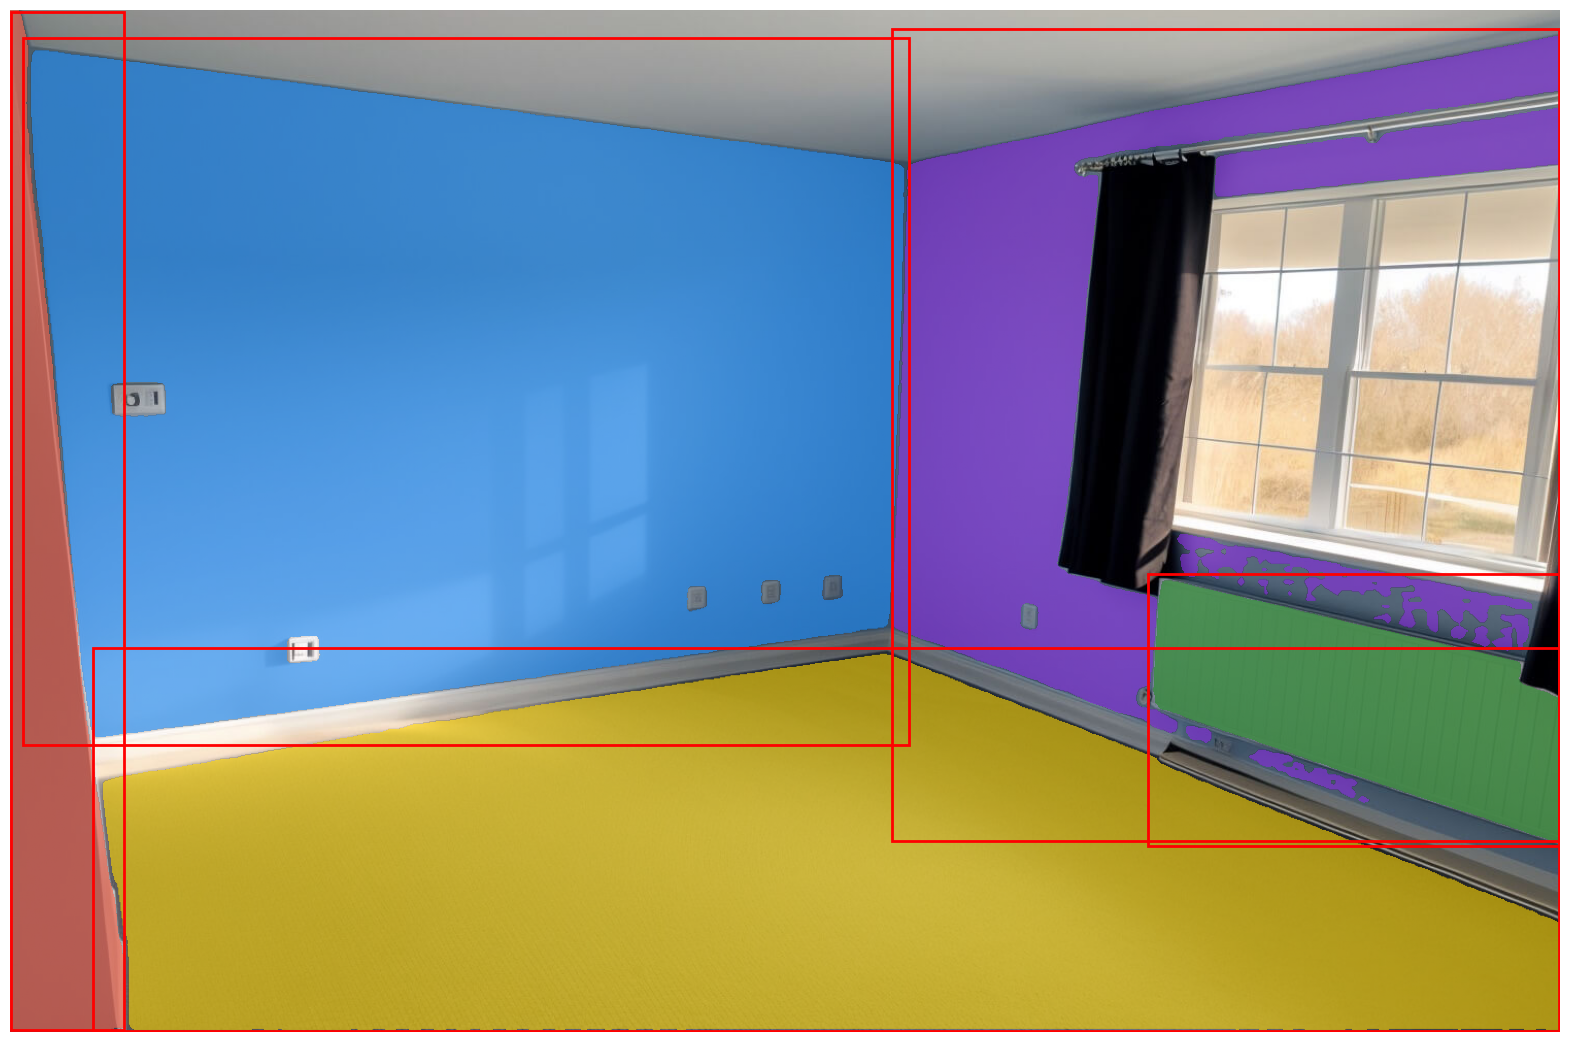

Getting wall mask from  D:\3d-recon\datasets\ASARoomImage\test\Living.JPG


wall_bboxes [[1.4415247e+03 1.2571411e+00 1.9983411e+03 1.1572300e+03]
 [4.0739554e+02 1.5518558e+02 4.7373019e+02 8.9526172e+02]]
wall_selected_points [[1771, 454], [435, 524]]
RUG:  0
No overlap
RUG BBOX 233.60004 877.8632 1797.8013 1186.3047
FLOOR BBOX 0.92364501953125 871.119384765625 1998.95703125 1332.525146484375
YES bbox is inside Floor area
floor_bboxes [[1.9236450e+00 8.7211938e+02 1.9979570e+03 1.3315251e+03]]
floor_selected_points [[780, 1318]]
rug_bboxes [[ 233.60004  877.8632  1797.8013  1186.3047 ]]
rug_to_floor_indices [[0]]
DONE GETTING BBOXES 13.017359018325806
(1333, 2000, 3)


DONE SAM EMBEDDING 16.94923210144043
onnx_coord.shape (1, 2, 2)
onnx_label.shape (1, 2)
(1333, 2000)
masks.shape (1, 1, 1333, 2000)
onnx_coord.shape (1, 2, 2)
onnx_label.shape (1, 2)
(1333, 2000)
masks.shape (1, 1, 1333, 2000)
onnx_coord.shape (1, 2, 2)
onnx_label.shape (1, 2)
(1333, 2000)
masks.shape (1, 1, 1333, 2000)
onnx_coord.shape (1, 2, 2)
onnx_label.shape (1, 2)
(1333, 2000)
masks.shape (1, 1, 1333, 2000)
(1, 1, 1333, 2000)
(1, 1, 1333, 2000)


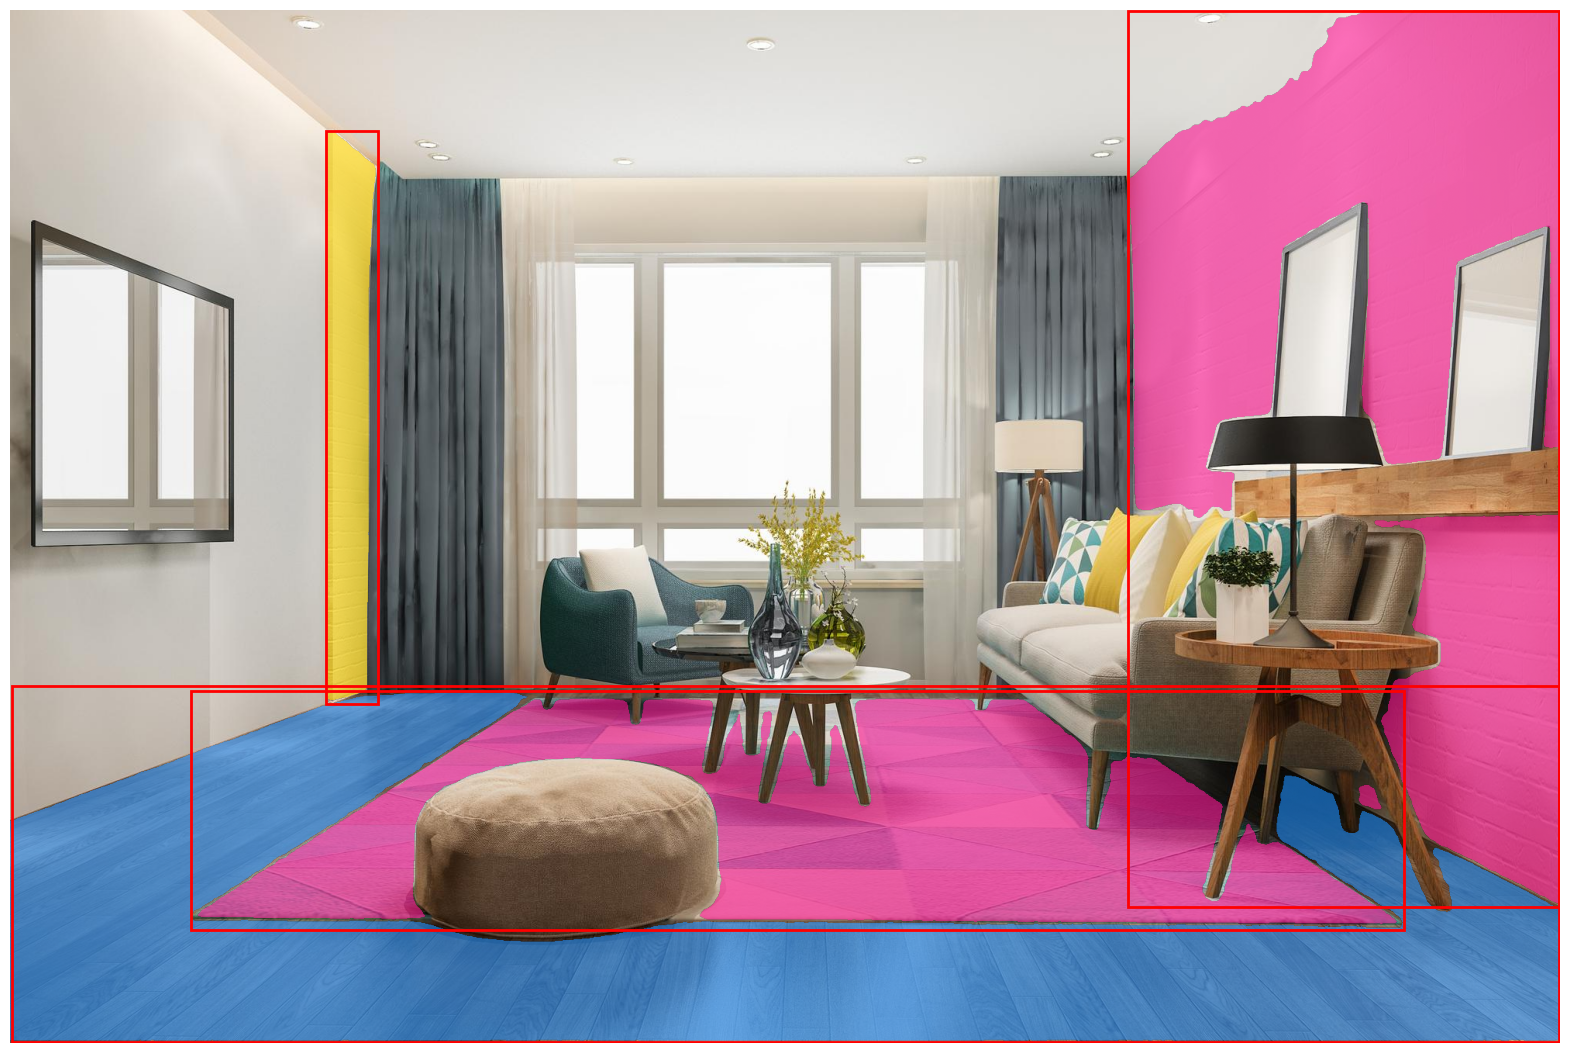

In [2]:
start_time = time.time()

FOLDER_PATH = r"D:\3d-recon\datasets\ASARoomImage"
FOLDER_PATH = r"D:\3d-recon\datasets\ASARoomImage\test"


OUTPUT_FOLDER_PATH = r"D:\3d-recon\Grounded-Segment-Anything\v1_final_output_onnx_vith"

for IMAGE_NAME in os.listdir(FOLDER_PATH):

  SOURCE_IMAGE_PATH = os.path.join(FOLDER_PATH, IMAGE_NAME)

  wall_bboxes, wall_selected_points = get_wall_bboxes_points(SOURCE_IMAGE_PATH)

  print("wall_bboxes", wall_bboxes)
  print("wall_selected_points", wall_selected_points)

  (floor_bboxes, 
  floor_selected_points, 
  rug_bboxes,
  rug_to_floor_indices) = get_floor_bboxes_points_with_rug(SOURCE_IMAGE_PATH)

  print("floor_bboxes", floor_bboxes)
  print("floor_selected_points", floor_selected_points)

  print("rug_bboxes", rug_bboxes)
  print("rug_to_floor_indices", rug_to_floor_indices)


  output = {'wall_bboxes': wall_bboxes,
        'wall_selected_points':wall_selected_points,
        'floor_bboxes':floor_bboxes,
        'floor_selected_points': floor_selected_points,
        'rug_bboxes': rug_bboxes,
        'rug_to_floor_indices':rug_to_floor_indices}

  print("DONE GETTING BBOXES", time.time()-start_time)



  image = cv2.imread(SOURCE_IMAGE_PATH)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  print(image.shape)

  checkpoint = r"./sam_vit_h_4b8939.pth"

  model_type = "vit_h"
  sam = sam_model_registry[model_type](checkpoint=checkpoint)


  sam.to(device='cuda')
  predictor = SamPredictor(sam)
  predictor.set_image(image)
  image_embedding = predictor.get_image_embedding().cpu().numpy()

  np.save("image_embedding_vith.npy", image_embedding)

  print("DONE SAM EMBEDDING", time.time()-start_time)


  onnx_model_path = r"D:\3d-recon\Grounded-Segment-Anything\sam_onnx_vith.onnx"
  ort_session = onnxruntime.InferenceSession(onnx_model_path)
  wall_masks = get_onnx_mask_from_bboxes_onnx(wall_bboxes, ort_session)

  ort_session = onnxruntime.InferenceSession(onnx_model_path)
  floor_masks = get_onnx_mask_from_bboxes_onnx(floor_bboxes, ort_session)

  rug_masks = []
  if len(rug_bboxes)>0:
    ort_session = onnxruntime.InferenceSession(onnx_model_path)
    rug_masks = get_onnx_mask_from_bboxes_onnx(rug_bboxes, ort_session)

  # Step 1: Convert to uint8 (0 and 255)
  mask_uint8 = (wall_masks[0].squeeze() * 255).astype(np.uint8)  # shape becomes (2657, 1920)


  plt.figure(figsize=(20,20))
  plt.imshow(image)
  for idx, (mask, bbox, point) in enumerate(zip(wall_masks, wall_bboxes, np.array(wall_selected_points))):
      
      print(mask.shape)
      show_mask(mask, plt.gca())
      show_box(bbox, plt.gca())
      # show_points(np.array([point]), labels=np.array([1]), ax=plt.gca())
      # plt.axis('off')
      # plt.savefig(os.path.join(OUTPUT_FOLDER_PATH,f"wall_{idx}_{IMAGE_NAME}") , bbox_inches='tight', pad_inches=0)
      # plt.show()
  

  # plt.imshow(image)
  for idx, (mask, bbox, point) in enumerate(zip(floor_masks, floor_bboxes, np.array(floor_selected_points))):
      # plt.figure(figsize=(20,20))
      # plt.imshow(image)
      show_mask(mask, plt.gca())
      show_box(bbox, plt.gca())
      # show_points(np.array([point]), labels=np.array([1]), ax=plt.gca())
      # plt.axis('off')
      # plt.savefig(os.path.join(OUTPUT_FOLDER_PATH,f"floor_{idx}_{IMAGE_NAME}"), bbox_inches='tight', pad_inches=0)
      # plt.show()
  

  if len(rug_masks)>0:
    # plt.imshow(image)

    for mask, bbox in zip(rug_masks, rug_bboxes):
        show_mask(mask, plt.gca())
        show_box(bbox, plt.gca())
  plt.axis('off')
  plt.savefig(os.path.join(OUTPUT_FOLDER_PATH,f"{IMAGE_NAME}.jpg"))
  plt.show()
